# Análise de Evasão de Clientes — TelecomX_BR

Este projeto tem como objetivo analisar os fatores que levam à evasão de clientes (*churn*) em uma empresa de telecomunicações, utilizando dados estruturados e ferramentas de análise estatística em Python.

## Etapa 1: Extração e Junção de Dados
Nesta etapa, importamos as bibliotecas necessárias, realizamos a extração dos dados a partir de uma fonte remota em formato JSON e desaninhamos os dicionários internos para construir um DataFrame plano (*flat table*).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import os

# Configurações visuais padrão para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# 1.1 Carga dos dados brutos 
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'
df = pd.read_json(url)

# 1.2 Desaninhando as colunas estruturadas como dicionários
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# Renomeando as colunas de forma explícita e limpa
df_customer.columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']
df_phone.columns = ['PhoneService', 'MultipleLines']
df_internet.columns = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_account.columns = ['Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']

# Combinando todas as tabelas em um único DataFrame de trabalho
df_clean = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

print(f"Extração concluída. Linhas: {df_clean.shape[0]} | Colunas: {df_clean.shape[1]}")

Extração concluída. Linhas: 7267 | Colunas: 21


## Etapa 2: Limpeza, Tratamento e Engenharia de Features
Para garantir a qualidade da análise, realizamos o tratamento de tipos de dados, correções de strings vazias na variável alvo (`Churn`) para evitar perda silenciosa de dados e eliminamos redundâncias nas variáveis categóricas. Também calculamos uma métrica derivada (`Charges.Daily`).

In [ ]:
# 2.1 Correção da coluna Charges.Total para numérico e imputação segura pela mediana
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')
median_total = df_clean['Charges.Total'].median()
df_clean['Charges.Total'] = df_clean['Charges.Total'].fillna(median_total)

# 2.2 Tratamento crítico de strings vazias na variável target (Churn)
df_clean['Churn'] = df_clean['Churn'].replace('', np.nan)
df_clean = df_clean.dropna(subset=['Churn'])

# 2.3 Padronização de categorias redundantes de serviços secundários
categorical_to_clean = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
for col in categorical_to_clean:
    df_clean[col] = df_clean[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# 2.4 Engenharia de Features: Estimativa de cobrança diária
df_clean['Charges.Daily'] = df_clean['Charges.Monthly'] / 30

# 2.5 Mapeamento seguro de variáveis binárias textuais para formato numérico (0 e 1)
binary_columns = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

for col in binary_columns:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0}).astype(int)

print("Tratamento de dados concluído com sucesso.")
print(f"Distribuição final do Target:\n{df_clean['Churn'].value_counts()}")

Tratamento de dados concluído com sucesso.
Distribuição final do Target:
Churn
0    5174
1    1869
Name: count, dtype: int64


## Etapa 3: Análise Exploratória de Dados (EDA) e Validação Estatística
Geramos visualizações focadas em padrões comportamentais e aplicamos testes de hipótese estatísticos (**Qui-Quadrado**) para comprovar a relevância das variáveis em relação ao cancelamento de serviços. Todos os gráficos gerados são salvos automaticamente para compor o relatório do repositório.

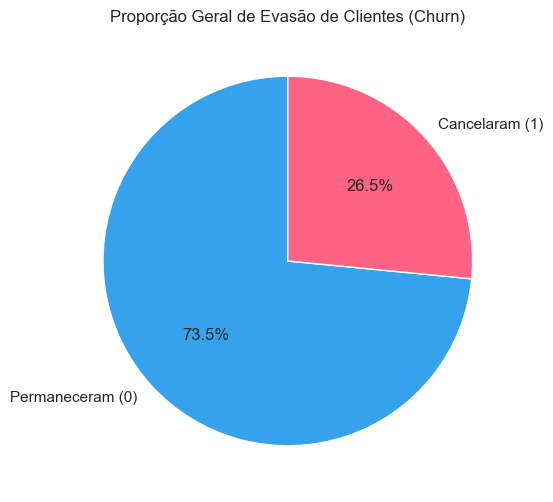

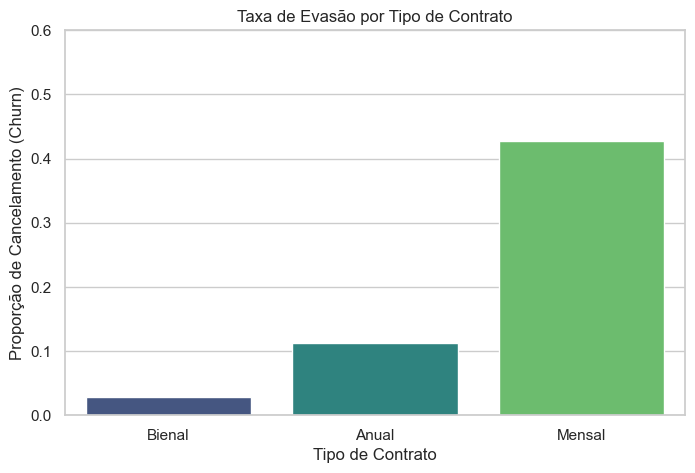

📊 Teste Qui-Quadrado (Contrato vs Churn) -> P-Valor: 0.000000


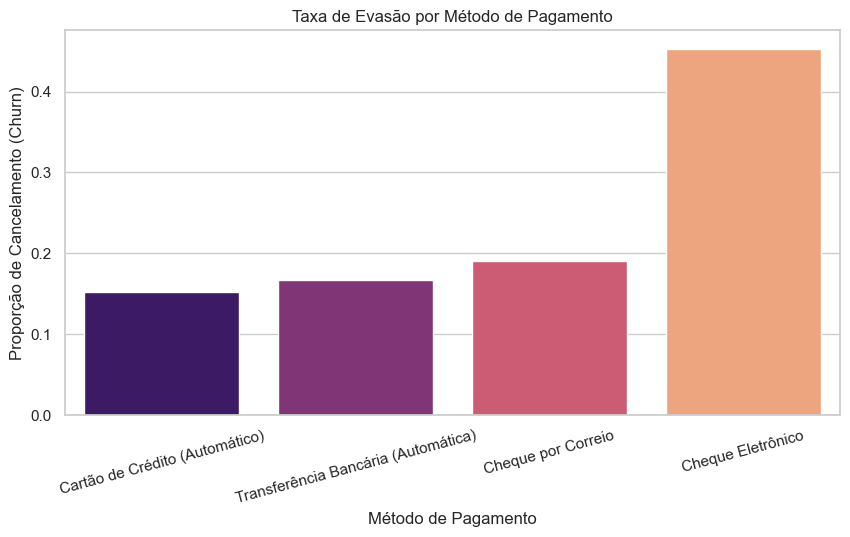

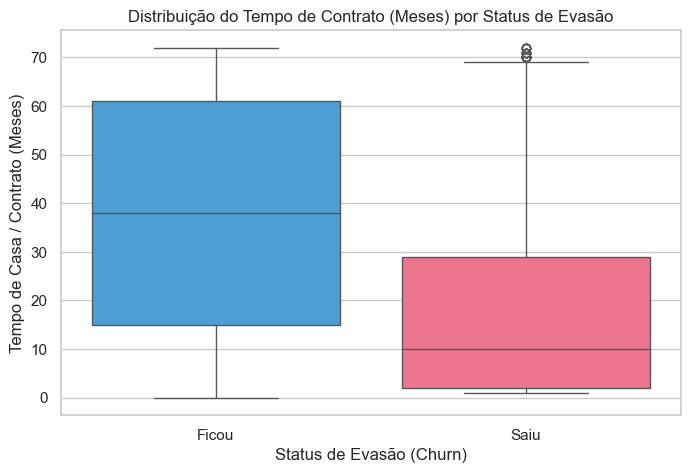

In [ ]:
# Cria o diretório de imagens caso não exista localmente
os.makedirs('images', exist_ok=True)

# 3.1 Proporção Geral de Churn
churn_dist = df_clean['Churn'].value_counts(normalize=True)
plt.figure(figsize=(6, 6))
plt.pie(churn_dist, labels=['Permaneceram (0)', 'Cancelaram (1)'], autopct='%1.1f%%', colors=['#36A2EB', '#FF6384'], startangle=90)
plt.title('Proporção Geral de Evasão de Clientes (Churn)')
plt.savefig('images/proporcao_churn.png', bbox_inches='tight', dpi=120)
plt.show()

# --- TRADUÇÃO COMPLETA DOS DADOS PARA OS GRÁFICOS ---
df_graficos = df_clean.copy()

# Traduzindo as linhas da coluna de Contratos
df_graficos['Contract'] = df_graficos['Contract'].replace({
    'Month-to-month': 'Mensal',
    'One year': 'Anual',
    'Two year': 'Bienal'
})

# Traduzindo as linhas da coluna de Métodos de Pagamento
df_graficos['PaymentMethod'] = df_graficos['PaymentMethod'].replace({
    'Electronic check': 'Cheque Eletrônico',
    'Mailed check': 'Cheque por Correio',
    'Bank transfer (automatic)': 'Transferência Bancária (Automática)',
    'Credit card (automatic)': 'Cartão de Crédito (Automático)'
})
# ----------------------------------------------------

# 3.2 Churn por Tipo de Contrato (Totalmente em Português)
churn_by_contract = df_graficos.groupby('Contract')['Churn'].mean().sort_values()
plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, hue=churn_by_contract.index, palette='viridis', legend=False)
plt.title('Taxa de Evasão por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Proporção de Cancelamento (Churn)')
plt.ylim(0, 0.6)
plt.savefig('images/churn_por_contrato.png', bbox_inches='tight', dpi=120)
plt.show()

# Validação Estatística com Teste Qui-Quadrado para a variável Contrato
contingency_contract = pd.crosstab(df_clean['Contract'], df_clean['Churn'])
chi2, p_contract, _, _ = chi2_contingency(contingency_contract)
print(f"📊 Teste Qui-Quadrado (Contrato vs Churn) -> P-Valor: {p_contract:.6f}")

# 3.3 Churn por Método de Pagamento (Totalmente em Português)
churn_by_payment = df_graficos.groupby('PaymentMethod')['Churn'].mean().sort_values()
plt.figure(figsize=(10, 5))
sns.barplot(x=churn_by_payment.index, y=churn_by_payment.values, hue=churn_by_payment.index, palette='magma', legend=False)
plt.title('Taxa de Evasão por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Proporção de Cancelamento (Churn)')
plt.xticks(rotation=15)
plt.savefig('images/churn_por_pagamento.png', bbox_inches='tight', dpi=120)
plt.show()

# 3.4 Distribuição de Tempo de Contrato (Tenure) por Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Churn', y='tenure', hue='Churn', palette=['#36A2EB', '#FF6384'], legend=False)
plt.title('Distribuição do Tempo de Contrato (Meses) por Status de Evasão')
plt.xlabel('Status de Evasão (Churn)')
plt.ylabel('Tempo de Casa / Contrato (Meses)')
plt.xticks([0, 1], ['Ficou', 'Saiu'])
plt.savefig('images/boxplot_tenure.png', bbox_inches='tight', dpi=120)
plt.show()

## Etapa 4: Exportação de Métricas de Apoio para o Relatório
Para finalizar o pipeline analítico, salvamos de forma automatizada um arquivo de texto com as tabelas de referência cruzada, facilitando a extração dos valores brutos que alimentarão as conclusões de negócio e o README.md.

In [ ]:
# Exportação automatizada de métricas descritivas
with open('resultados_churn.txt', 'w', encoding='utf-8') as f:
    f.write("=== RELATÓRIO DE SUPORTE E METRICAS DE CHURN ===\n\n")
    f.write(f"Significância Estatística (Qui-Quadrado Contrato): p-value = {p_contract}\n\n")
    f.write("Taxa de Evasão por Tipo de Serviço de Internet:\n")
    f.write(df_clean.groupby('InternetService')['Churn'].mean().to_markdown() + "\n\n")
    f.write("Taxa de Evasão por Perfil do Cliente (Idoso / SeniorCitizen):\n")
    f.write(df_clean.groupby('SeniorCitizen')['Churn'].mean().to_markdown() + "\n\n")
    f.write("Média de Custos Mensais agregados por Churn:\n")
    f.write(df_clean.groupby('Churn')['Charges.Monthly'].mean().to_markdown() + "\n")

print("Arquivo 'resultados_churn.txt' criado com sucesso.")

Arquivo 'resultados_churn.txt' criado com sucesso.
